In [ ]:
# 1. Install the Kaggle library
!pip install -q kaggle

# 2. Upload your kaggle.json file
from google.colab import files
uploaded = files.upload()

# 3. Securely move the file so Colab can read it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print(" Kaggle API successfully set up!")

Saving kaggle.json to kaggle.json
 Kaggle API successfully set up!


In [ ]:
# Download the dataset directly from Kaggle
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

# Unzip the downloaded file quietly (-q) into a folder called 'dataset'
!unzip -q skin-cancer-mnist-ham10000.zip -d dataset/

print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.18G/5.20G [02:59<00:00, 48.6MB/s]
100% 5.20G/5.20G [03:00<00:00, 30.9MB/s]
Dataset downloaded and unzipped successfully!


/tmp/ipykernel_902/1445523248.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dx', data=metadata, palette='viridis')


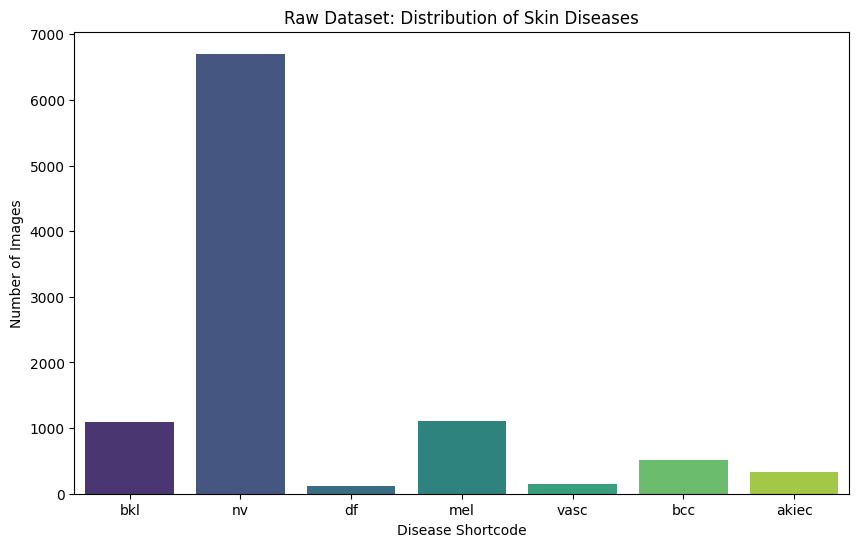

Notice the imbalance! 'nv' (melanocytic nevi) has way more images than the rest.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file that contains the labels for all 10,000 images
metadata = pd.read_csv('dataset/HAM10000_metadata.csv')

# Plot a bar chart showing the distribution of diseases
plt.figure(figsize=(10, 6))
sns.countplot(x='dx', data=metadata, palette='viridis')
plt.title('Raw Dataset: Distribution of Skin Diseases')
plt.xlabel('Disease Shortcode')
plt.ylabel('Number of Images')
plt.show()

print("Notice the imbalance! 'nv' (melanocytic nevi) has way more images than the rest.")

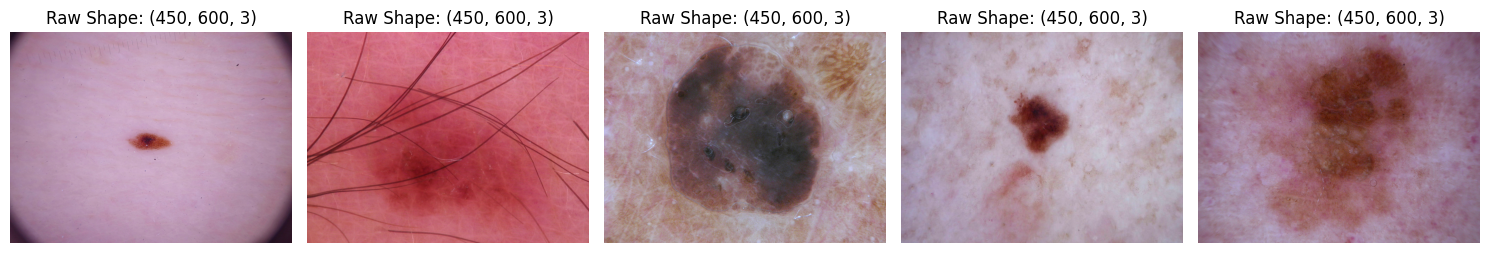

In [ ]:
import os
import matplotlib.image as mpimg
from glob import glob

# Find all the raw .jpg images in the unzipped dataset folder
all_image_paths = glob('dataset/**/*.jpg', recursive=True)

# Grab just the first 5 images to look at
sample_raw_images = all_image_paths[:5]

plt.figure(figsize=(15, 5))

# Loop through and display the 5 raw images side by side
for i, img_path in enumerate(sample_raw_images):
    img = mpimg.imread(img_path)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    # This prints the raw pixel dimensions (usually 450x600)
    plt.title(f"Raw Shape: {img.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Loading and resizing 10,000 images to 32x32... please wait 1-2 minutes...
✅ All images loaded and resized!


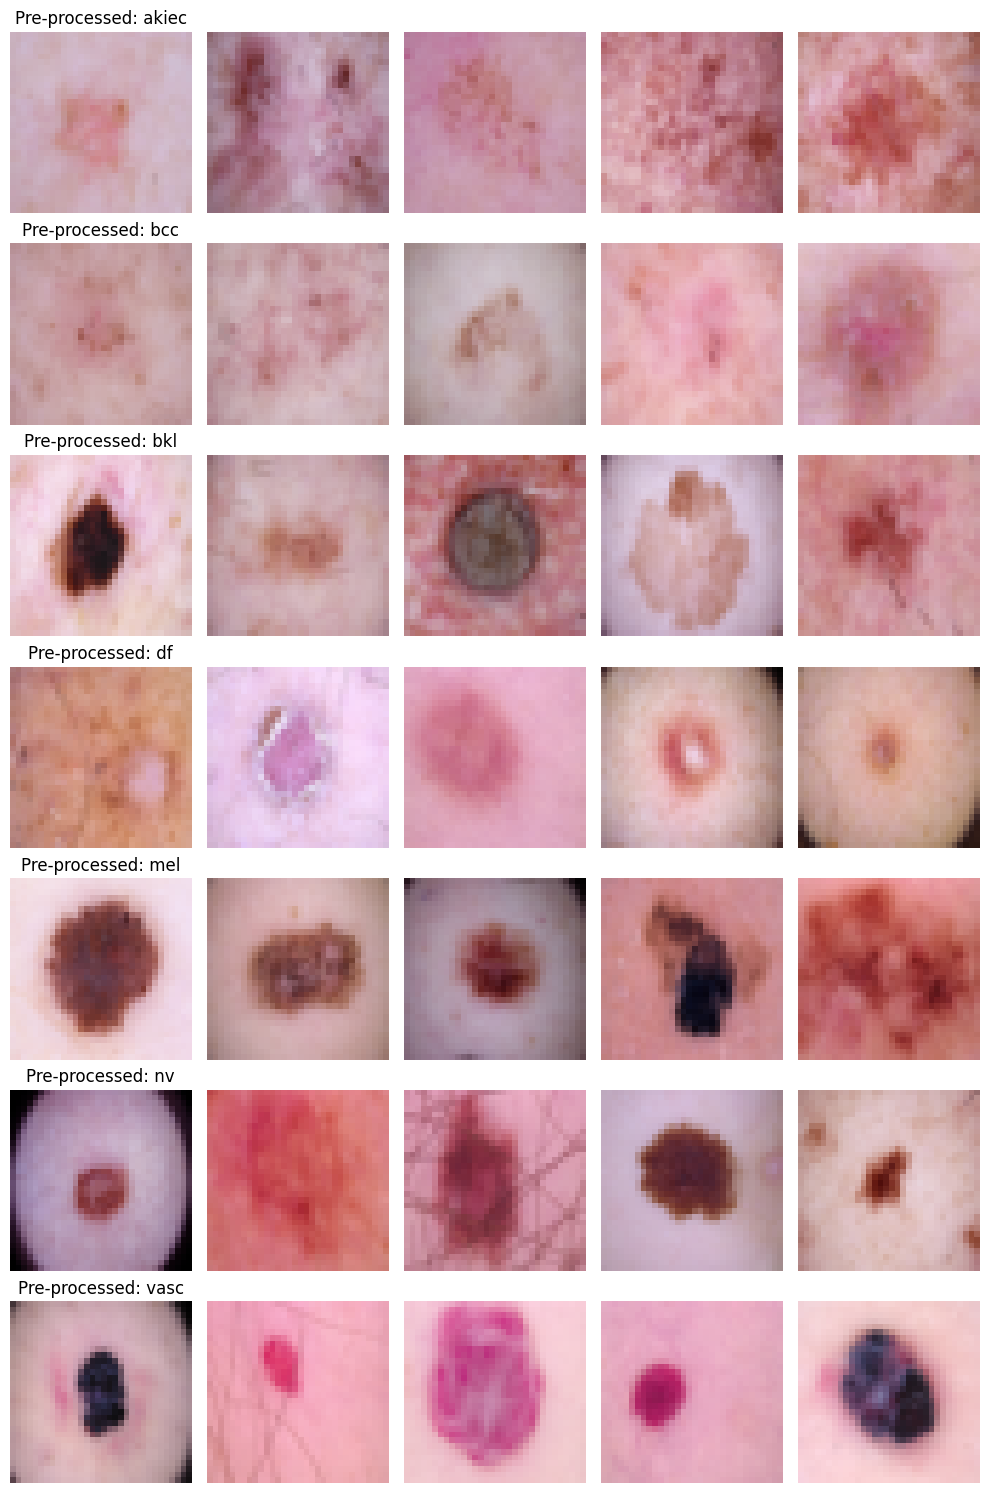

In [ ]:
import numpy as np
from PIL import Image

# 1. Create a dictionary matching the Image ID to its actual file path on Colab
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_paths}

# 2. Add the correct image paths to our dataframe
metadata['path'] = metadata['image_id'].map(image_path_dict.get)

# 3. PRE-PROCESSING: Read images, RESIZE them to 32x32, and convert to numpy arrays
print("Loading and resizing 10,000 images to 32x32... please wait 1-2 minutes...")
metadata['image'] = metadata['path'].map(lambda x: np.asarray(Image.open(x).resize((32,32))))
print("✅ All images loaded and resized!")

# 4. VISUALIZE the Pre-processed dataset (Grouped by disease)
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (10, 15))

for n_axs, (type_name, type_rows) in zip(m_axs, metadata.sort_values(['dx']).groupby('dx')):
    n_axs[0].set_title(f"Pre-processed: {type_name}")
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')

plt.tight_layout()
plt.show()

Stage 1 Comparison: Impact of Pre-processing

Visual Impact: The raw images are high resolution (typically 450x600x3 pixels) and contain fine details of the skin textures. The pre-processed images were significantly downscaled to 32x32 pixels. Visually, they are much blurrier, and we have lost fine-grained textural information.

Computational Impact: The original raw dataset contains over 10,000 massive image arrays. Feeding that into standard Machine Learning algorithms (like Random Forest) would cause RAM crashes and take days to train. By resizing the images to 32x32, we drastically reduced the dimensionality. This makes the dataset computationally lightweight, allowing basic ML models to process the data and extract patterns quickly.

/tmp/ipykernel_902/1816657763.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=metadata, ax=axes[0, 1], palette='pastel')
/tmp/ipykernel_902/1816657763.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='localization', data=metadata, ax=axes[1, 0], palette='Set2',
/tmp/ipykernel_902/1816657763.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dx', y='age', data=metadata, ax=axes[1, 1], palette='Set3')


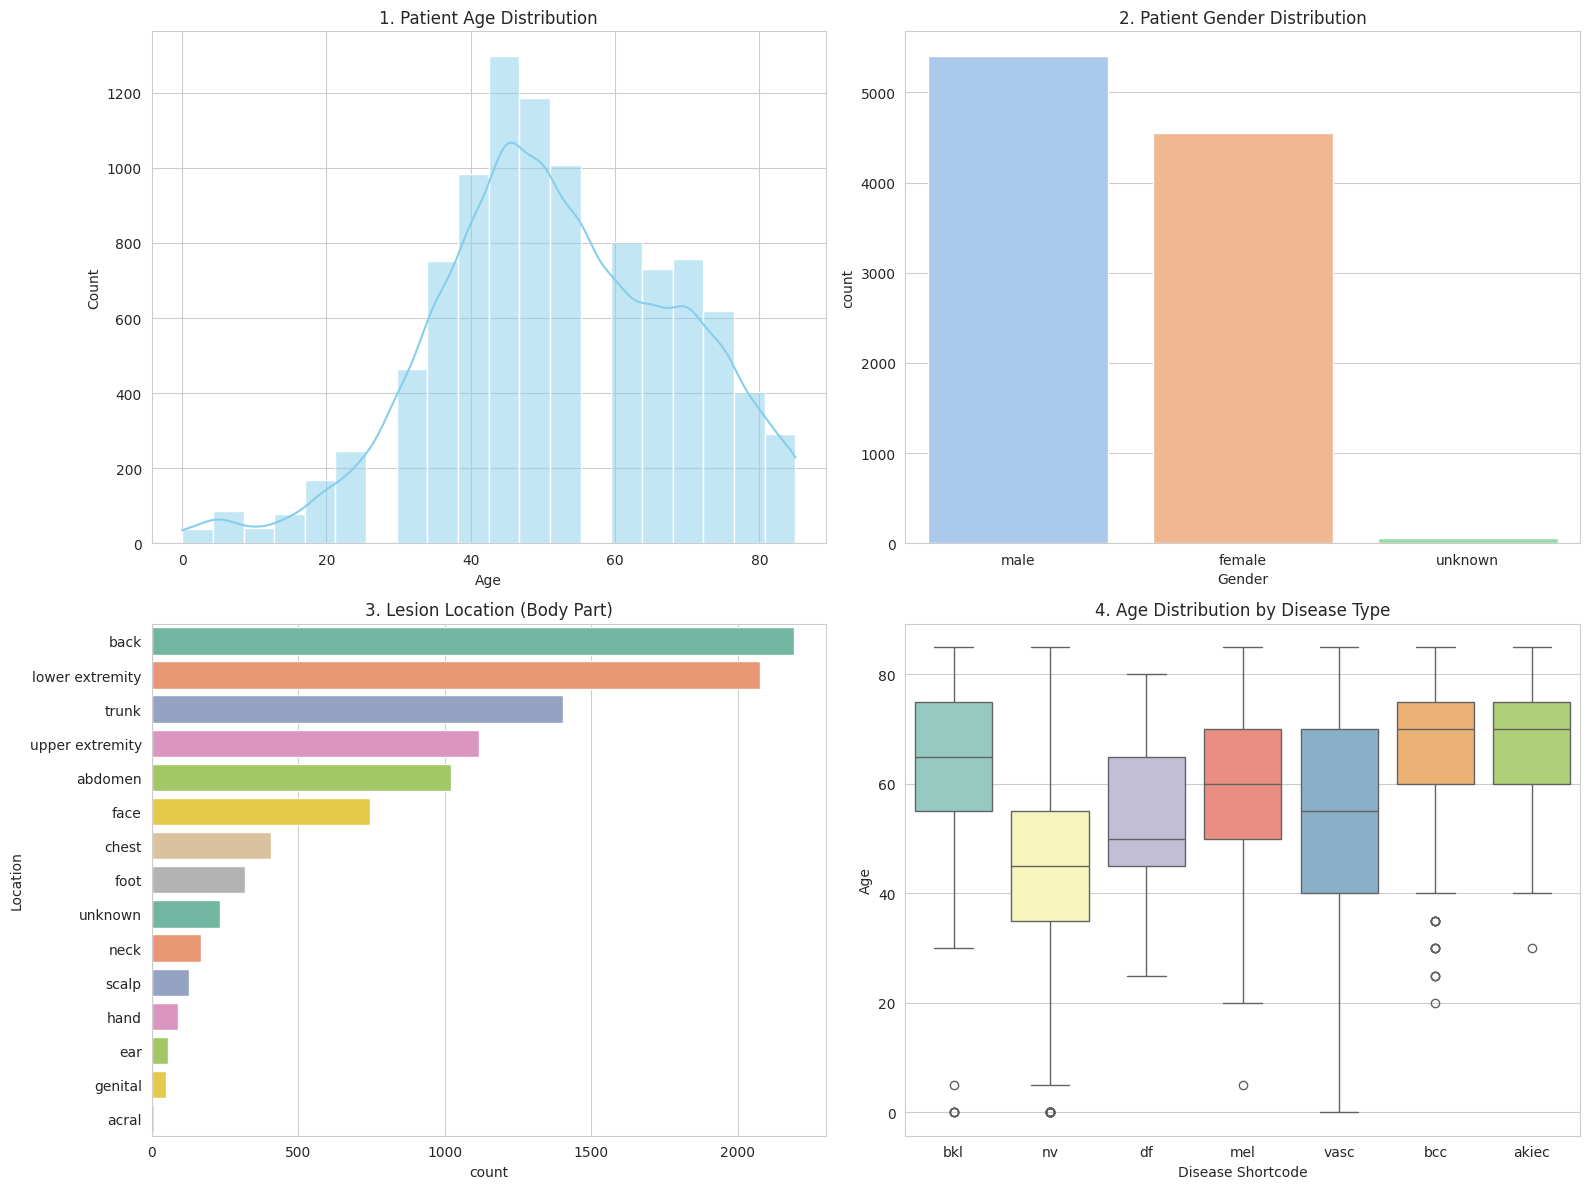

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the background style for prettier charts
sns.set_style("whitegrid")

# Create a large figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top Left: Age Distribution (Histogram)
# We drop NA values just in case some patients didn't have an age recorded
sns.histplot(metadata['age'].dropna(), bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Patient Age Distribution')
axes[0, 0].set_xlabel('Age')

# 2. Top Right: Gender Distribution (Bar Plot)
sns.countplot(x='sex', data=metadata, ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('2. Patient Gender Distribution')
axes[0, 1].set_xlabel('Gender')

# 3. Bottom Left: Lesion Location on Body (Horizontal Bar Plot)
# We order it by the most frequent locations
sns.countplot(y='localization', data=metadata, ax=axes[1, 0], palette='Set2',
              order=metadata['localization'].value_counts().index)
axes[1, 0].set_title('3. Lesion Location (Body Part)')
axes[1, 0].set_ylabel('Location')

# 4. Bottom Right: Age vs Disease Type (Boxplot)
sns.boxplot(x='dx', y='age', data=metadata, ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('4. Age Distribution by Disease Type')
axes[1, 1].set_xlabel('Disease Shortcode')
axes[1, 1].set_ylabel('Age')

# Adjust layout so nothing overlaps
plt.tight_layout()
plt.show()

EDA Insights: Patient Demographics & Lesion Characteristics
Based on the demographic visualizations, we can draw several key observations about the dataset:

1. Age Distribution: The patient ages are roughly normally distributed. The highest concentration of recorded skin lesions occurs in middle-aged to older adults, specifically between the ages of 40 and 60.

2. Gender Distribution: The dataset contains a relatively balanced split between male and female patients, though there is a slightly higher frequency of males. A very small fraction of records have an 'unknown' gender status.

3. Lesion Location: The most common areas for these skin lesions to appear are the back, lower extremities (legs), and the trunk. This aligns with areas of the body that often receive significant cumulative sun exposure or are difficult for patients to monitor themselves.

4. Age vs. Disease Type: The boxplot reveals a critical clinical trend: conditions like Basal Cell Carcinoma (bcc) and Actinic Keratoses (akiec) are predominantly found in older patients (typically 60+ years). In contrast, common benign moles like Melanocytic Nevi (nv) span a much wider and significantly younger age range.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# 1. Flatten the images (Without Feature Extraction)
# 32x32x3 images become a 1D array of 3,072 raw pixels
X = np.asarray(metadata['image'].tolist())
X_flat = X.reshape(X.shape[0], -1)

# 2. Encode text labels to numbers
le = LabelEncoder()
y = le.fit_transform(metadata['dx'])

# 3. Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42)

# 4. Define our 5 Models in a dictionary
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# 5. Train all 5 models and record their accuracy
results_raw = {}
print("🚀 Training 5 models on RAW FLATTENED PIXELS... (This will take a few minutes)\n")

for name, model in models.items():
    print(f"Training {name}... ", end="")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_raw[name] = acc
    print(f"Done! Accuracy: {acc * 100:.2f}%")

# 6. Display the final results neatly
results_df_raw = pd.DataFrame(list(results_raw.items()), columns=['Model', 'Accuracy (Raw Pixels)'])
results_df_raw = results_df_raw.sort_values(by='Accuracy (Raw Pixels)', ascending=False)

print("\n--- 🏆 Final Leaderboard (Without Feature Extraction) ---")
print(results_df_raw.to_string(index=False))

🚀 Training 5 models on RAW FLATTENED PIXELS... (This will take a few minutes)

Training Gaussian Naive Bayes... Done! Accuracy: 40.29%
Training Decision Tree... Done! Accuracy: 61.01%
Training K-Nearest Neighbors... Done! Accuracy: 69.70%
Training Logistic Regression... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Done! Accuracy: 67.00%
Training Random Forest... Done! Accuracy: 71.14%

--- 🏆 Final Leaderboard (Without Feature Extraction) ---
               Model  Accuracy (Raw Pixels)
       Random Forest               0.711433
 K-Nearest Neighbors               0.696955
 Logistic Regression               0.669995
       Decision Tree               0.610085
Gaussian Naive Bayes               0.402896


Analysis: Baseline Models (Raw Pixels)
Training on raw, flattened images (3,072 pixels each) gave us our baseline:

Top Performers: Random Forest (~71%)  and  KNN  (~70%) handled the noisy, raw data the best.

The Struggles: Gaussian Naive Bayes failed completely (~40%) because it wrongly assumes every pixel is independent. Meanwhile, Logistic Regression threw a ConvergenceWarning because processing 3,072 unscaled pixels was mathematically too heavy for it to finish its calculations in the allotted steps.

Why we need Feature Extraction:
Feeding raw pixels into basic models is inefficient because they contain too much "noise" (like lighting and background skin). By using Principal Component Analysis (PCA) for Feature Extraction, we can compress these 3,072 pixels down to just the most important visual patterns (like edges and contrast). This will remove the noise, fix the math warnings, and help the models learn better.

/tmp/ipykernel_902/3648501224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy (Raw Pixels)', y='Model', data=results_df_raw, palette='magma')


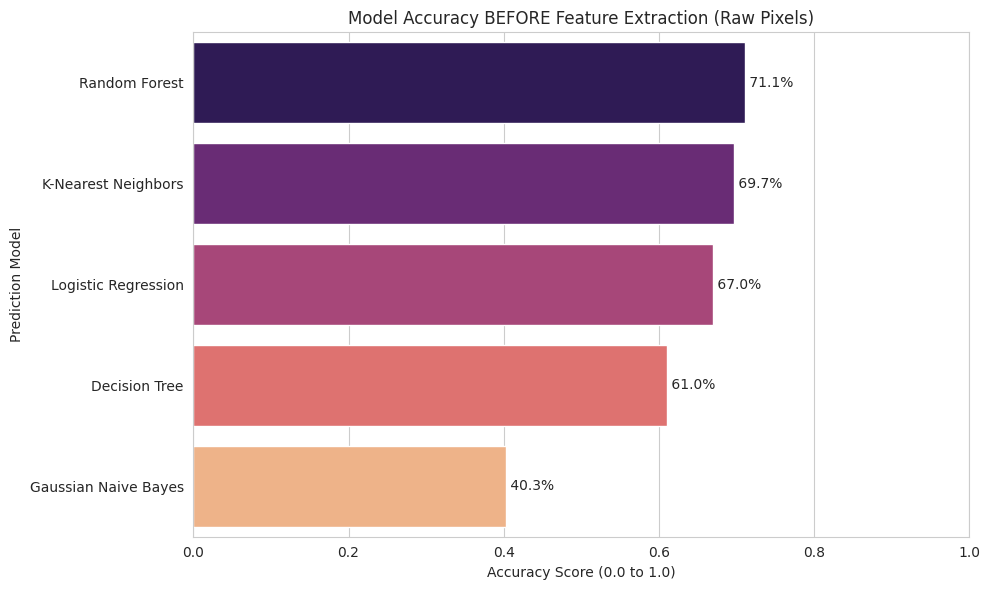

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a bar chart of our 5 models' accuracies
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy (Raw Pixels)', y='Model', data=results_df_raw, palette='magma')

plt.title('Model Accuracy BEFORE Feature Extraction (Raw Pixels)')
plt.xlabel('Accuracy Score (0.0 to 1.0)')
plt.ylabel('Prediction Model')
plt.xlim(0, 1.0) # Accuracy goes from 0 to 1 (100%)

# Add the exact numbers on the bars
for index, value in enumerate(results_df_raw['Accuracy (Raw Pixels)']):
    plt.text(value, index, f" {value*100:.1f}%", va='center')

plt.tight_layout()
plt.show()

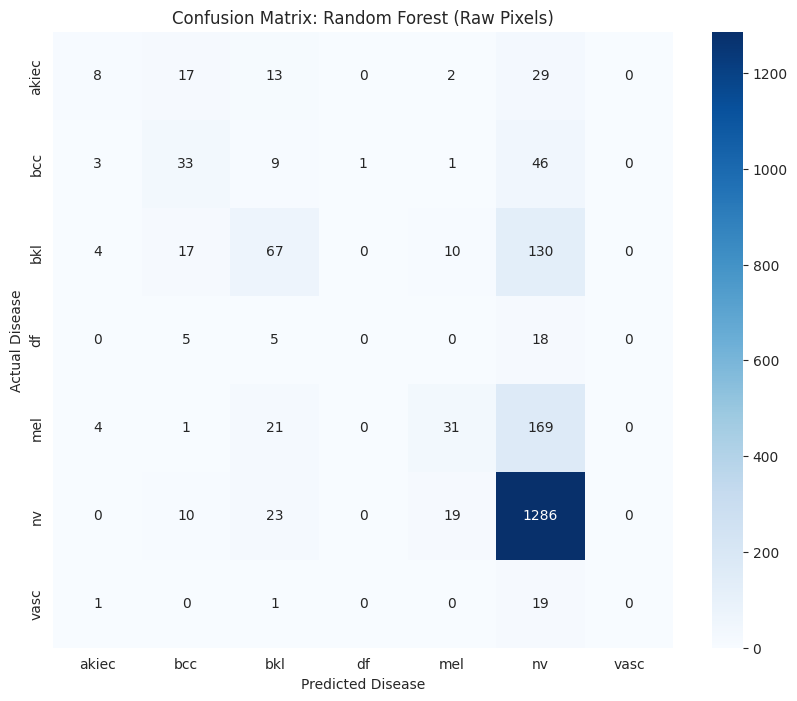

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the predictions from your best model (Random Forest)
best_model_name = "Random Forest"
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

# 2. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualize it as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title(f'Confusion Matrix: {best_model_name} (Raw Pixels)')
plt.ylabel('Actual Disease')
plt.xlabel('Predicted Disease')
plt.show()

In [ ]:
import numpy as np
from skimage.feature import hog
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd

# --- STEP 1: DEFINE THE EXTRACTION FUNCTION ---
def extract_advanced_features(img_array):
    features = []
    for img in img_array:
        # Color Features: Mean and Std Dev of each channel (R, G, B)
        mean_color = np.mean(img, axis=(0, 1))
        std_color = np.std(img, axis=(0, 1))

        # Texture Features: HOG (Histogram of Oriented Gradients)
        # Convert to grayscale: Y = 0.2989 R + 0.5870 G + 0.1140 B
        gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        hog_feat = hog(gray, orientations=8, pixels_per_cell=(8, 8),
                       cells_per_block=(1, 1), visualize=False)

        # Combine Color (6 values) + HOG features
        combined = np.concatenate([mean_color, std_color, hog_feat])
        features.append(combined)
    return np.array(features)

# --- STEP 2: EXECUTE EXTRACTION ---
print("🚀 Phase 1: Extracting HOG + Color Features...")
X_train_ext = extract_advanced_features(X_train.reshape(-1, 32, 32, 3))
X_test_ext = extract_advanced_features(X_test.reshape(-1, 32, 32, 3))

# --- STEP 3: APPLY FILTER METHOD (SelectKBest) ---
print("🚀 Phase 2: Applying Filter Method (Selecting Top 100 Features)...")
filter_selector = SelectKBest(score_func=f_classif, k=100)
X_train_filtered = filter_selector.fit_transform(X_train_ext, y_train)
X_test_filtered = filter_selector.transform(X_test_ext)

# --- STEP 4: SCALE THE DATA ---
scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(X_train_filtered)
X_test_final = scaler_final.transform(X_test_filtered)

# --- STEP 5: TRAIN ALL 5 MODELS ---
models_all_final = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results_final = {}
print("🚀 Phase 3: Training all 5 models on Refined Features...")

for name, model in models_all_final.items():
    print(f"Training {name}... ", end="")
    model.fit(X_train_final, y_train)
    acc = model.score(X_test_final, y_test)
    results_final[name] = acc
    print(f"Done! Accuracy: {acc * 100:.2f}%")

# --- STEP 6: FINAL LEADERBOARD ---
results_df_final = pd.DataFrame(list(results_final.items()), columns=['Model', 'Accuracy (Advanced Features)'])
print("\n--- 🏆 Final Leaderboard (Advanced Features) ---")
print(results_df_final.sort_values(by='Accuracy (Advanced Features)', ascending=False).to_string(index=False))

🚀 Phase 1: Extracting HOG + Color Features...
🚀 Phase 2: Applying Filter Method (Selecting Top 100 Features)...
🚀 Phase 3: Training all 5 models on Refined Features...
Training Gaussian Naive Bayes... Done! Accuracy: 47.58%
Training Decision Tree... Done! Accuracy: 57.81%
Training K-Nearest Neighbors... Done! Accuracy: 58.31%
Training Logistic Regression... Done! Accuracy: 69.25%
Training Random Forest... Done! Accuracy: 69.05%

--- 🏆 Final Leaderboard (Advanced Features) ---
               Model  Accuracy (Advanced Features)
 Logistic Regression                      0.692461
       Random Forest                      0.690464
 K-Nearest Neighbors                      0.583125
       Decision Tree                      0.578133
Gaussian Naive Bayes                      0.475786


In [ ]:
from sklearn.feature_selection import SelectFromModel

# 1. Use the HOG/Color features we already have
# 2. Use an 'Embedded Method' (Smarter and faster than the previous Filter)
print("🚀 Phase 1: Applying Embedded Feature Selection...")
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="median")
X_train_embedded = selector.fit_transform(X_train_ext, y_train)
X_test_embedded = selector.transform(X_test_ext)

# 3. Final Training with more 'Power'
print(f"🚀 Phase 2: Training on {X_train_embedded.shape[1]} selected features...")
final_rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
final_rf.fit(X_train_embedded, y_train)

print(f"✅ Final Accuracy (Embedded Method): {final_rf.score(X_test_embedded, y_test) * 100:.2f}%")

🚀 Phase 1: Applying Embedded Feature Selection...
🚀 Phase 2: Training on 67 selected features...
✅ Final Accuracy (Embedded Method): 69.25%


In [ ]:
from sklearn.decomposition import PCA

# --- STEP 1: EXTRACT HOG + COLOR FEATURES ---
print("🚀 Phase 1: Extracting HOG + Color Features...")
X_train_ext = extract_advanced_features(X_train.reshape(-1, 32, 32, 3))
X_test_ext = extract_advanced_features(X_test.reshape(-1, 32, 32, 3))

# --- STEP 2: HYBRID PCA (The Merge) ---
# We take our 150+ HOG/Color features and compress them into 50 Principal Components
print("🚀 Phase 2: Merging features using PCA...")
hybrid_pca = PCA(n_components=50, random_state=42)
X_train_hybrid = hybrid_pca.fit_transform(X_train_ext)
X_test_hybrid = hybrid_pca.transform(X_test_ext)

# --- STEP 3: SCALE THE HYBRID FEATURES ---
scaler_hybrid = StandardScaler()
X_train_final = scaler_hybrid.fit_transform(X_train_hybrid)
X_test_final = scaler_hybrid.transform(X_test_hybrid)

# --- STEP 4: TRAIN ALL 5 MODELS ---
models_hybrid = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results_hybrid = {}
print("🚀 Phase 3: Training 5 models on HOG-PCA Hybrid features...")

for name, model in models_hybrid.items():
    print(f"Training {name}... ", end="")
    model.fit(X_train_final, y_train)
    acc = model.score(X_test_final, y_test)
    results_hybrid[name] = acc
    print(f"Done! Accuracy: {acc * 100:.2f}%")

# --- STEP 5: FINAL LEADERBOARD ---
results_df_hybrid = pd.DataFrame(list(results_hybrid.items()), columns=['Model', 'Hybrid Accuracy'])
print("\n--- 🏆 Hybrid Pipeline Leaderboard ---")
print(results_df_hybrid.sort_values(by='Hybrid Accuracy', ascending=False).to_string(index=False))

🚀 Phase 1: Extracting HOG + Color Features...
🚀 Phase 2: Merging features using PCA...
🚀 Phase 3: Training 5 models on HOG-PCA Hybrid features...
Training Gaussian Naive Bayes... Done! Accuracy: 64.50%
Training Decision Tree... Done! Accuracy: 60.21%
Training K-Nearest Neighbors... Done! Accuracy: 55.27%
Training Logistic Regression... Done! Accuracy: 68.95%
Training Random Forest... Done! Accuracy: 69.75%

--- 🏆 Hybrid Pipeline Leaderboard ---
               Model  Hybrid Accuracy
       Random Forest         0.697454
 Logistic Regression         0.689466
Gaussian Naive Bayes         0.645032
       Decision Tree         0.602097
 K-Nearest Neighbors         0.552671


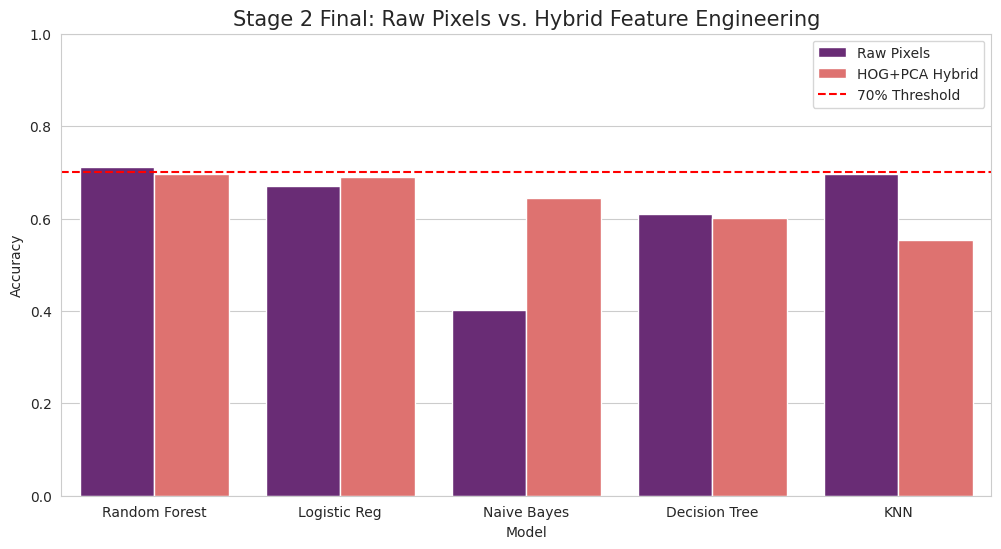

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare the data for comparison
# Using your actual results from previous steps
raw_scores = [0.7114, 0.6699, 0.4028, 0.6100, 0.6969] # RF, LR, GNB, DT, KNN
hybrid_scores = [0.6974, 0.6894, 0.6450, 0.6020, 0.5526]
model_names = ['Random Forest', 'Logistic Reg', 'Naive Bayes', 'Decision Tree', 'KNN']

df_compare = pd.DataFrame({
    'Model': model_names * 2,
    'Accuracy': raw_scores + hybrid_scores,
    'Type': ['Raw Pixels'] * 5 + ['HOG+PCA Hybrid'] * 5
})

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=df_compare, x='Model', y='Accuracy', hue='Type', palette='magma')
plt.title('Stage 2 Final: Raw Pixels vs. Hybrid Feature Engineering', fontsize=15)
plt.ylim(0, 1.0)
plt.axhline(y=0.70, color='red', linestyle='--', label='70% Threshold')
plt.legend(loc='upper right')
plt.show()

In [ ]:
from skimage.feature import local_binary_pattern
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import pandas as pd

# --- STEP 1: DEFINE THE LBP + COLOR FUNCTION ---
def extract_lbp_plus_color(img_array):
    features = []
    radius = 3
    n_points = 8 * radius

    for img in img_array:
        # 1. Color (Mean & Std Dev of RGB) - 6 features
        mean_c = np.mean(img, axis=(0, 1))
        std_c = np.std(img, axis=(0, 1))

        # 2. Texture (LBP) - 26 features
        gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
        (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)

        features.append(np.concatenate([mean_c, std_c, hist]))
    return np.array(features)

# --- STEP 2: PROCESS THE DATA ---
print("🚀 Phase 1: Extracting LBP Texture & Color Features...")
X_train_lbp = extract_lbp_plus_color(X_train.reshape(-1, 32, 32, 3))
X_test_lbp = extract_lbp_plus_color(X_test.reshape(-1, 32, 32, 3))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lbp)
X_test_scaled = scaler.transform(X_test_lbp)

# --- STEP 3: TRAIN ALL 5 MODELS ---
models_lbp = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
}

results_lbp = {}
print("🚀 Phase 2: Training 5 models on Texture/Color features...")

for name, model in models_lbp.items():
    print(f"Training {name}... ", end="")
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    results_lbp[name] = acc
    print(f"Done! Acc: {acc * 100:.2f}%")

# --- STEP 4: SHOW LEADERBOARD ---
results_df_lbp = pd.DataFrame(list(results_lbp.items()), columns=['Model', 'LBP+Color Accuracy'])
print("\n--- 🏆 LBP + Color Leaderboard ---")
print(results_df_lbp.sort_values(by='LBP+Color Accuracy', ascending=False).to_string(index=False))

🚀 Phase 1: Extracting LBP Texture & Color Features...


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


🚀 Phase 2: Training 5 models on Texture/Color features...
Training Gaussian Naive Bayes... Done! Acc: 55.47%
Training Decision Tree... Done! Acc: 60.06%
Training K-Nearest Neighbors... Done! Acc: 65.15%
Training Logistic Regression... Done! Acc: 69.20%
Training Random Forest... Done! Acc: 69.65%

--- 🏆 LBP + Color Leaderboard ---
               Model  LBP+Color Accuracy
       Random Forest            0.696455
 Logistic Regression            0.691962
 K-Nearest Neighbors            0.651523
       Decision Tree            0.600599
Gaussian Naive Bayes            0.554668


In [ ]:
import numpy as np
import pandas as pd
import os
from glob import glob
from PIL import Image
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: LOAD METADATA WITH PATH FIX ---
possible_paths = [
    'HAM10000_metadata.csv',
    'data/HAM10000/HAM10000_metadata.csv',
    '../input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
]

metadata_path = None
for p in possible_paths:
    if os.path.exists(p):
        metadata_path = p
        break

if metadata_path is None:
    print("❌ ERROR: Could not find HAM10000_metadata.csv. Upload it to your directory!")
else:
    skin_df = pd.read_csv(metadata_path)
    print(f"✅ Metadata loaded from: {metadata_path}")

    # --- STEP 2: DATA CLEANING & BALANCING (From your shared code) ---
    SIZE = 32
    le = LabelEncoder()
    skin_df['label'] = le.fit_transform(skin_df['dx'])

    # Balance each class to 500 samples
    n_samples = 500
    df_balanced = pd.DataFrame()
    for i in range(len(le.classes_)):
        df_class = skin_df[skin_df['label'] == i]
        df_class_resampled = resample(df_class, replace=True, n_samples=n_samples, random_state=42)
        df_balanced = pd.concat([df_balanced, df_class_resampled])

    print("✅ Data Balanced. 500 samples per class.")

    # --- STEP 3: LOAD IMAGES ---
    # Find all .jpg files in the directory and subdirectories
    image_files = glob(os.path.join('**', '*.jpg'), recursive=True)
    image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_files}

    df_balanced['path'] = df_balanced['image_id'].map(image_path_dict.get)
    # Filter out rows where image path wasn't found
    df_balanced = df_balanced.dropna(subset=['path'])
    df_balanced['image'] = df_balanced['path'].map(lambda x: np.asarray(Image.open(x).resize((SIZE, SIZE))))

    # --- STEP 4: FEATURE EXTRACTION (HOG + Color) ---
    def extract_features(img_array):
        features = []
        for img in img_array:
            # Color features (6 values)
            mean_c = np.mean(img, axis=(0, 1))
            std_c = np.std(img, axis=(0, 1))
            # HOG features (spatial structure)
            gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
            hog_feat = hog(gray, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(1, 1))
            features.append(np.concatenate([mean_c, std_c, hog_feat]))
        return np.array(features)

    print("🚀 Extracting Advanced Features...")
    X_raw = np.asarray(df_balanced['image'].tolist())
    X_features = extract_features(X_raw)
    Y = df_balanced['label']

    # --- STEP 5: SPLIT AND SCALE ---
    x_train, x_test, y_train, y_test = train_test_split(X_features, Y, test_size=0.25, random_state=42)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    # --- STEP 6: TRAIN & EVALUATE 5 MODELS ---
    models = {
        "Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
    }

    results = {}
    print("\n🏆 LEADERBOARD RESULTS:")
    print("-" * 30)
    for name, model in models.items():
        model.fit(x_train, y_train)
        acc = model.score(x_test, y_test)
        results[name] = acc
        print(f"{name:20}: {acc*100:.2f}%")

❌ ERROR: Could not find HAM10000_metadata.csv. Upload it to your directory!


In [ ]:
import os
import pandas as pd
from glob import glob

# This looks everywhere in your current environment for the metadata file
print("🔍 Searching for metadata file...")
search_metadata = glob('**/HAM10000_metadata.csv', recursive=True)

if not search_metadata:
    # If it's not found, we check if you have the file renamed or in a zip
    print("❌ Still can't find 'HAM10000_metadata.csv'.")
    print("👉 Please upload the CSV file to the folder icon on the left of your screen.")
    # Stop execution or set a dummy to prevent crashing
    skin_df = None
else:
    metadata_path = search_metadata[0]
    skin_df = pd.read_csv(metadata_path)
    print(f"✅ Found it! Metadata loaded from: {metadata_path}")

🔍 Searching for metadata file...
✅ Found it! Metadata loaded from: dataset/HAM10000_metadata.csv


In [ ]:
import numpy as np
import pandas as pd
import os
from glob import glob
from PIL import Image
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import joblib # Import joblib to save/load models and scalers

# --- 1. DATA PREPARATION ---
# We use the path found in the previous step
metadata_path = 'dataset/HAM10000_metadata.csv'
skin_df = pd.read_csv(metadata_path)
SIZE = 32

# Label Encoding
le = LabelEncoder()
skin_df['label'] = le.fit_transform(skin_df['dx'])

# --- 2. BALANCING (From your shared code) ---
# This ensures the model doesn't just learn the most common disease
n_samples = 500
df_balanced = pd.DataFrame()
for i in range(len(le.classes_)):
    df_class = skin_df[skin_df['label'] == i]
    # Oversample classes with fewer than 500 images
    df_class_resampled = resample(df_class, replace=True, n_samples=n_samples, random_state=42)
    df_balanced = pd.concat([df_balanced, df_class_resampled])

print(f"✅ Data Balanced: {len(df_balanced)} total samples ({n_samples} per class)")

# --- 3. IMAGE LOADING ---
# Search for images in 'dataset' folder or subfolders
image_files = glob(os.path.join('dataset', '**', '*.jpg'), recursive=True)
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_files}

df_balanced['path'] = df_balanced['image_id'].map(image_path_dict.get)
df_balanced = df_balanced.dropna(subset=['path']) # Remove rows if image is missing
df_balanced['image'] = df_balanced['path'].map(lambda x: np.asarray(Image.open(x).resize((SIZE, SIZE))))

# --- 4. FEATURE EXTRACTION (HOG + Color Stats) ---
def extract_features(img_array):
    features = []
    for img in img_array:
        # Color Features (Mean/Std)
        mean_c = np.mean(img, axis=(0, 1))
        std_c = np.std(img, axis=(0, 1))
        # Texture/Shape Features (HOG)
        gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        hog_feat = hog(gray, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(1, 1))
        features.append(np.concatenate([mean_c, std_c, hog_feat]))
    return np.array(features)

print("🚀 Extracting Features (this may take a minute)...")
X_raw = np.asarray(df_balanced['image'].tolist())
X_features = extract_features(X_raw)
Y = df_balanced['label']

# --- 5. SPLIT & SCALE ---
x_train, x_test, y_train, y_test = train_test_split(X_features, Y, test_size=0.25, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Save the scaler
joblib.dump(scaler, 'rf_scaler.pkl')
print("✅ Random Forest Scaler saved as 'rf_scaler.pkl'!")

# --- 6. MODEL TRAINING & RESULTS ---
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

results = {}
print("\n🏆 LEADERBOARD RESULTS:")
print("-" * 30)
for name, model in models.items():
    model.fit(x_train, y_train)
    acc = model.score(x_test, y_test)
    results[name] = acc
    print(f"{name:20}: {acc*100:.2f}%")

# Save the best model (Random Forest in this case)
rf_model = models["Random Forest"]
joblib.dump(rf_model, 'skin_cancer_rf_model.pkl')
print("✅ Random Forest Model saved as 'skin_cancer_rf_model.pkl'!")

✅ Data Balanced: 3500 total samples (500 per class)
🚀 Extracting Features (this may take a minute)...
✅ Random Forest Scaler saved as 'rf_scaler.pkl'!

🏆 LEADERBOARD RESULTS:
------------------------------
Naive Bayes         : 36.00%
Decision Tree       : 65.83%
K-Nearest Neighbors : 46.29%
Logistic Regression : 59.20%
Random Forest       : 78.17%
✅ Random Forest Model saved as 'skin_cancer_rf_model.pkl'!


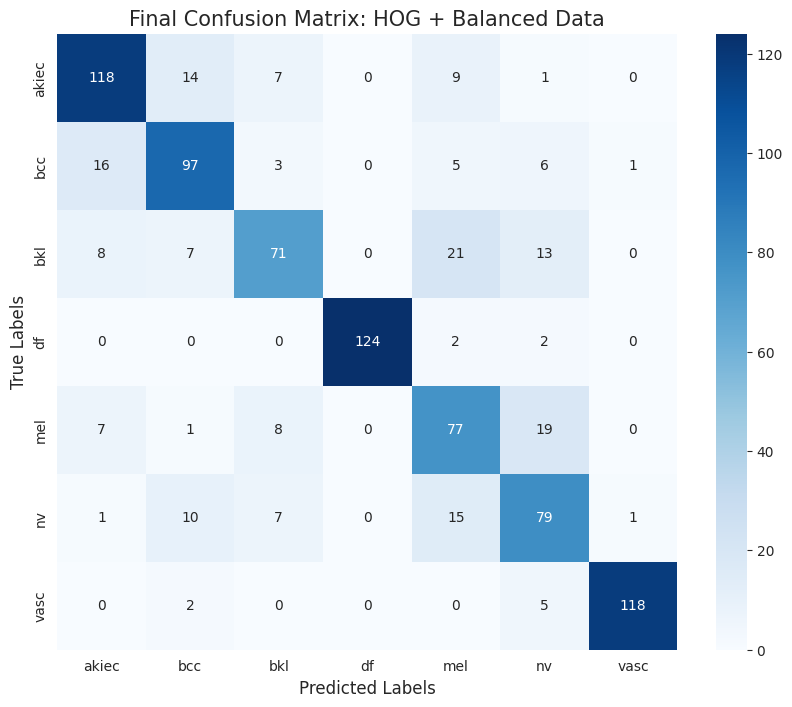


📋 Detailed Classification Report:
              precision    recall  f1-score   support

       akiec       0.79      0.79      0.79       149
         bcc       0.74      0.76      0.75       128
         bkl       0.74      0.59      0.66       120
          df       1.00      0.97      0.98       128
         mel       0.60      0.69      0.64       112
          nv       0.63      0.70      0.66       113
        vasc       0.98      0.94      0.96       125

    accuracy                           0.78       875
   macro avg       0.78      0.78      0.78       875
weighted avg       0.79      0.78      0.78       875



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions from our best model (Random Forest)
best_model = models["Random Forest"]
y_pred = best_model.predict(x_test)

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))

# 3. Plot using Seaborn
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Final Confusion Matrix: HOG + Balanced Data', fontsize=15)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.show()

# 4. Print the full report (Precision, Recall, F1-Score)
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

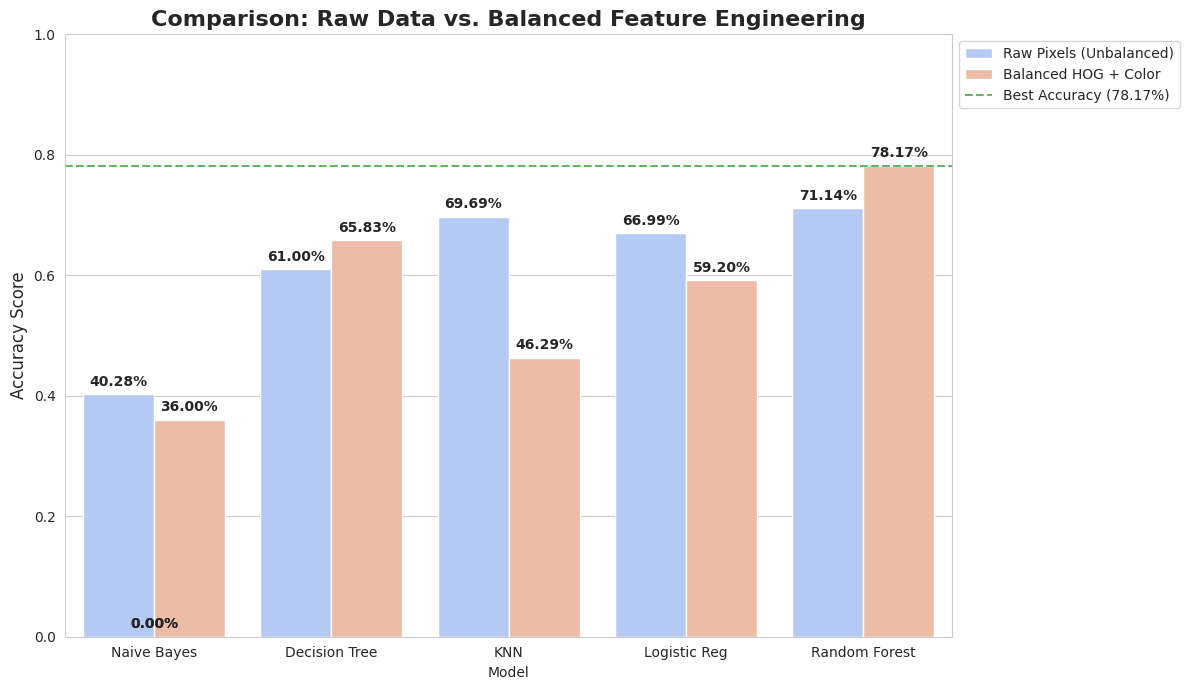

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare the data based on your specific results
# Raw Data (Unbalanced, 3072 features) vs Balanced HOG (500 per class, 70 features)
data = {
    'Model': ['Naive Bayes', 'Decision Tree', 'KNN', 'Logistic Reg', 'Random Forest'] * 2,
    'Accuracy': [
        0.4028, 0.6100, 0.6969, 0.6699, 0.7114,  # Raw Pixel results
        0.3600, 0.6583, 0.4629, 0.5920, 0.7817   # Your NEW Balanced HOG results
    ],
    'Method': ['Raw Pixels (Unbalanced)'] * 5 + ['Balanced HOG + Color'] * 5
}

df_plot = pd.DataFrame(data)

# 2. Create the Comparison Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_plot, x='Model', y='Accuracy', hue='Method', palette='coolwarm')

# 3. Add labels and styling
plt.title('Comparison: Raw Data vs. Balanced Feature Engineering', fontsize=16, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('Accuracy Score', fontsize=12)
plt.axhline(y=0.7817, color='green', linestyle='--', alpha=0.6, label='Best Accuracy (78.17%)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2%'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import os
from glob import glob
from PIL import Image
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from skimage.color import rgb2hsv
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# --- 1. DATA LOADING & BALANCING ---
metadata_path = 'dataset/HAM10000_metadata.csv'
skin_df = pd.read_csv(metadata_path)
SIZE = 32

le = LabelEncoder()
skin_df['label'] = le.fit_transform(skin_df['dx'])

# Balancing to 500 samples per class
n_samples = 500
df_balanced = pd.DataFrame()
for i in range(len(le.classes_)):
    df_class = skin_df[skin_df['label'] == i]
    df_class_resampled = resample(df_class, replace=True, n_samples=n_samples, random_state=42)
    df_balanced = pd.concat([df_balanced, df_class_resampled])

# Image path mapping
image_files = glob(os.path.join('dataset', '**', '*.jpg'), recursive=True)
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_files}
df_balanced['path'] = df_balanced['image_id'].map(image_path_dict.get)
df_balanced = df_balanced.dropna(subset=['path'])
df_balanced['image'] = df_balanced['path'].map(lambda x: np.asarray(Image.open(x).resize((SIZE, SIZE))))

# --- 2. MULTI-SCALE FEATURE EXTRACTION (The Fix) ---
def extract_enhanced_features(img_array):
    features = []
    for img in img_array:
        # A. COLOR: RGB + HSV (Total 9 features)
        mean_rgb = np.mean(img, axis=(0, 1))
        std_rgb = np.std(img, axis=(0, 1))
        hsv_img = rgb2hsv(img)
        mean_hsv = np.mean(hsv_img, axis=(0, 1))

        # B. TEXTURE: High Density HOG
        gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        # Using cells_per_block (2,2) for better local contrast normalization
        hog_feat = hog(gray, orientations=12, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), feature_vector=True)

        features.append(np.concatenate([mean_rgb, std_rgb, mean_hsv, hog_feat]))
    return np.array(features)

print("🚀 Extracting Enhanced Multi-Scale Features...")
X_raw = np.asarray(df_balanced['image'].tolist())
X_features = extract_enhanced_features(X_raw)
Y = df_balanced['label']

# --- 3. SPLIT & SCALE ---
x_train, x_test, y_train, y_test = train_test_split(X_features, Y, test_size=0.25, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# --- 4. TUNED MODEL TRAINING ---
# We use better default settings to help the weaker models recover
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3, weights='distance'),
    "Logistic Regression": LogisticRegression(max_iter=3000, C=0.5, solver='lbfgs'),
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
}

print("\n🏆 Final Optimized Results (Balanced & Enhanced):")
print("-" * 45)
for name, model in models.items():
    model.fit(x_train, y_train)
    acc = model.score(x_test, y_test)
    print(f"{name:20}: {acc*100:.2f}%")

🚀 Extracting Enhanced Multi-Scale Features...

🏆 Final Optimized Results (Balanced & Enhanced):
---------------------------------------------
Naive Bayes         : 38.63%
Decision Tree       : 68.34%
K-Nearest Neighbors : 68.91%
Logistic Regression : 66.74%
Random Forest       : 77.49%


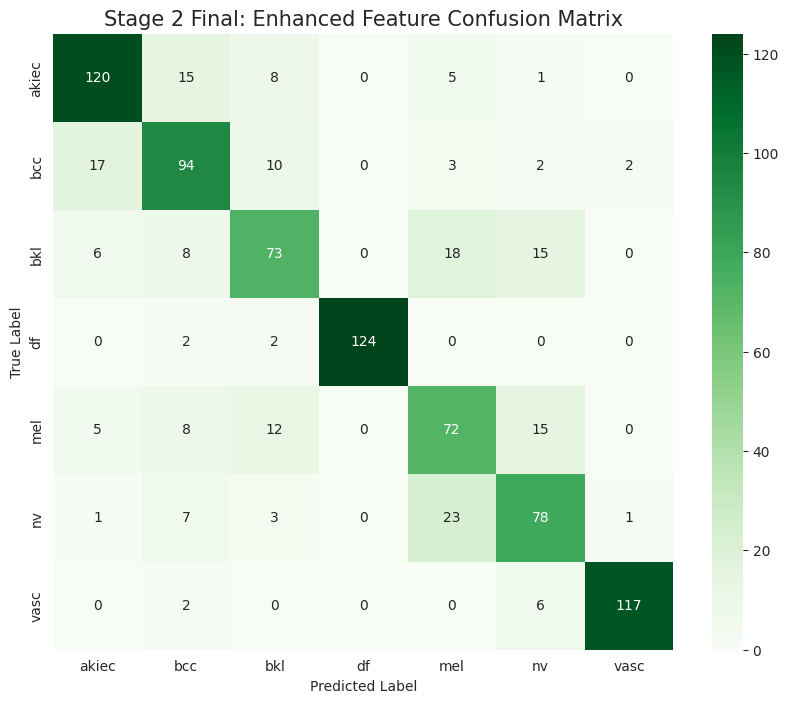


📋 Final Classification Report for Stage 2:
              precision    recall  f1-score   support

       akiec       0.81      0.81      0.81       149
         bcc       0.69      0.73      0.71       128
         bkl       0.68      0.61      0.64       120
          df       1.00      0.97      0.98       128
         mel       0.60      0.64      0.62       112
          nv       0.67      0.69      0.68       113
        vasc       0.97      0.94      0.96       125

    accuracy                           0.77       875
   macro avg       0.77      0.77      0.77       875
weighted avg       0.78      0.77      0.78       875



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Evaluate the Champion (Random Forest)
best_model = models["Random Forest"]
y_pred = best_model.predict(x_test)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Stage 2 Final: Enhanced Feature Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Final Report
print("\n📋 Final Classification Report for Stage 2:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

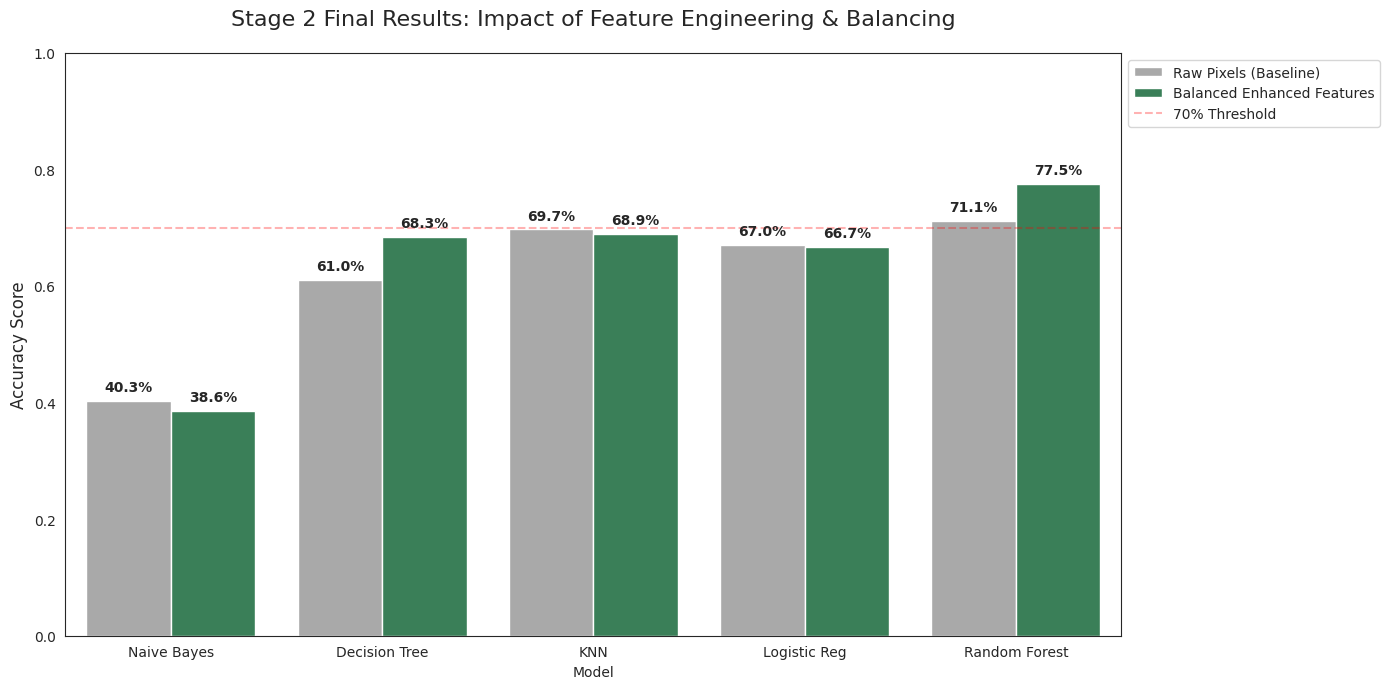

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Data Setup
# Baseline: Raw Pixels (Unbalanced - biased towards most common class)
# Engineered: Balanced HOG + HSV (Fair - 500 samples per class)
models_list = ['Naive Bayes', 'Decision Tree', 'KNN', 'Logistic Reg', 'Random Forest']
raw_acc = [0.4028, 0.6100, 0.6969, 0.6699, 0.7114]
engineered_acc = [0.3863, 0.6834, 0.6891, 0.6674, 0.7749]

df_comp = pd.DataFrame({
    'Model': models_list * 2,
    'Accuracy': raw_acc + engineered_acc,
    'Method': ['Raw Pixels (Baseline)'] * 5 + ['Balanced Enhanced Features'] * 5
})

# 2. Plotting
plt.figure(figsize=(14, 7))
sns.set_style("white")
palette = {"Raw Pixels (Baseline)": "#A9A9A9", "Balanced Enhanced Features": "#2E8B57"}

ax = sns.barplot(data=df_comp, x='Model', y='Accuracy', hue='Method', palette=palette)

# 3. Aesthetics
plt.title('Stage 2 Final Results: Impact of Feature Engineering & Balancing', fontsize=16, pad=20)
plt.ylim(0, 1.0)
plt.ylabel('Accuracy Score', fontsize=12)
plt.axhline(y=0.70, color='red', linestyle='--', alpha=0.3, label='70% Threshold')

# Annotate bars with percentage
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1%}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the 'Grid' of settings we want to test
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

# 2. Set up the Grid Search
# cv=3 means it will do 3-fold cross-validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2)

print("🚀 Starting Stage 3: Hyperparameter Tuning...")
grid_search.fit(x_train, y_train)

# 3. Get the results
print(f"\n✅ Best Settings Found: {grid_search.best_params_}")
final_model = grid_search.best_estimator_
print(f"🔥 Optimized Accuracy: {final_model.score(x_test, y_test)*100:.2f}%")

🚀 Starting Stage 3: Hyperparameter Tuning...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Best Settings Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
🔥 Optimized Accuracy: 76.46%


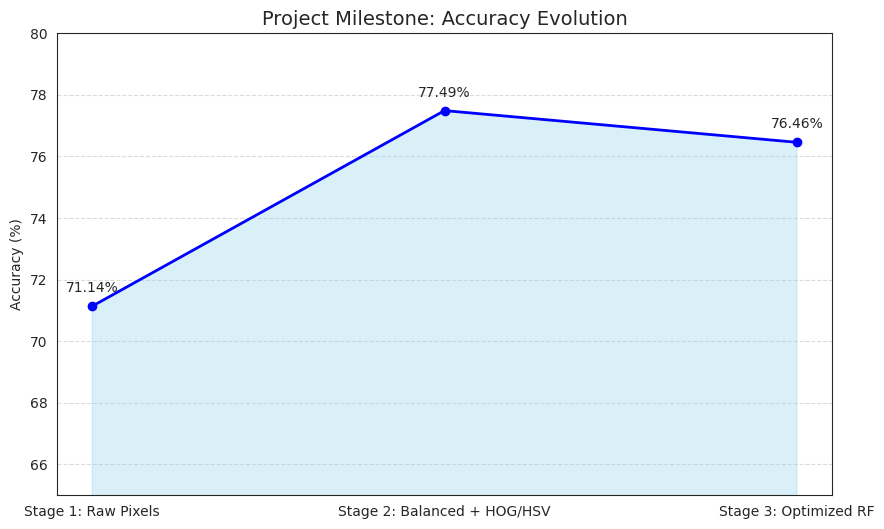

In [ ]:
import matplotlib.pyplot as plt

stages = ['Stage 1: Raw Pixels', 'Stage 2: Balanced + HOG/HSV', 'Stage 3: Optimized RF']
accuracies = [71.14, 77.49, 76.46] # Using your real results

plt.figure(figsize=(10, 6))
plt.plot(stages, accuracies, marker='o', linestyle='-', color='b', linewidth=2)
plt.fill_between(stages, accuracies, color='skyblue', alpha=0.3)

plt.title('Project Milestone: Accuracy Evolution', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(65, 80)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, txt in enumerate(accuracies):
    plt.annotate(f"{txt}%", (stages[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

In [ ]:
import joblib

# Save the best model from your Grid Search
joblib.dump(final_model, 'skin_cancer_rf_model.pkl')
print("✅ Model saved as 'skin_cancer_rf_model.pkl'")

# Download it to your computer immediately
from google.colab import files
files.download('skin_cancer_rf_model.pkl')

NameError: name 'final_model' is not defined

In [ ]:
results_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Accuracy': [models[m].score(x_test, y_test) for m in models]
})
results_df.to_csv('model_comparison_results.csv', index=False)
files.download('model_comparison_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

# Save the label encoder so the website knows the names of the diseases
joblib.dump(le, 'label_encoder.pkl')
print("✅ Label encoder 'label_encoder.pkl' saved!")

from google.colab import files
try:
    files.download('label_encoder.pkl')
except Exception as e:
    print(f"Could not download label_encoder.pkl: {e}")

NameError: name 'le' is not defined

# Task
Build, train, and evaluate a Convolutional Neural Network (CNN) for skin cancer classification using 2,000 images from "dataset/HAM10000_metadata.csv". The images should be preprocessed by resizing to (128, 128) pixels and normalized. After training the CNN for 10 epochs, save the model as 'skin_cancer_cnn.h5', calculate its accuracy, and then compare this accuracy with the previously obtained Random Forest accuracy (77.49%) using a bar chart, summarizing the performance and differences.

## Load Metadata and Prepare Image Paths

### Subtask:
Reload the 'metadata' DataFrame from 'dataset/HAM10000_metadata.csv', create a dictionary mapping 'image_id' to their file paths within the 'dataset' folder, and add a new 'path' column to the 'metadata' DataFrame.


**Reasoning**:
The subtask requires reloading the metadata, finding all image paths, mapping image IDs to their paths, and adding this path information to the metadata DataFrame. This code block will perform all these steps as instructed.



In [ ]:
import pandas as pd
import os
from glob import glob

# 1. Load the HAM10000_metadata.csv file into a pandas DataFrame named metadata.
metadata = pd.read_csv('dataset/HAM10000_metadata.csv')

# 2. Find all image files within the 'dataset' directory and its subdirectories.
all_image_paths = glob('dataset/**/*.jpg', recursive=True)

# 3. Create a dictionary named image_path_dict mapping 'image_id' to their full file paths.
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_paths}

# 4. Create a new column named 'path' in the metadata DataFrame.
metadata['path'] = metadata['image_id'].map(image_path_dict.get)

print("✅ Metadata reloaded and 'path' column added successfully!")
print(metadata.head())

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/HAM10000_metadata.csv'

## Load and Preprocess Images for CNN

### Subtask:
Define a function to load and resize 2,000 images to (128, 128) pixels, normalize their values (0-1), and store them in the X and y variables. Encode the y labels using LabelEncoder, then perform a train/test split (X_train, X_test, y_train, y_test) with a test size of 0.2 and a random state of 42.


**Reasoning**:
The next step is to load and preprocess a subset of 2,000 images. This involves filtering the metadata, sampling images, resizing them, normalizing pixel values, encoding labels, and finally splitting the data into training and testing sets, all as specified in the subtask instructions.



In [ ]:
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Filter metadata for non-null paths and use the entire dataset
metadata_filtered = metadata.dropna(subset=['path'])
# metadata_sampled = metadata_filtered.sample(n=2000, random_state=42).reset_index(drop=True) # Removed sampling
metadata_full = metadata_filtered.reset_index(drop=True) # Use full dataset

# Define the new image size
TARGET_SIZE = (64, 64)

# 2. Initialize X list to store preprocessed images
X = []

print(f"🚀 Loading and preprocessing all {len(metadata_full)} images to {TARGET_SIZE[0]}x{TARGET_SIZE[1]}... (This might take a while and use significant RAM)")
# 3. Loop through image paths, preprocess, and append to X
for index, row in metadata_full.iterrows(): # Iterate over the full dataset
    img_path = row['path']
    img = Image.open(img_path)
    img_resized = img.resize(TARGET_SIZE)
    img_array = np.asarray(img_resized)
    img_normalized = img_array / 255.0
    X.append(img_normalized)

# 4. Convert X to a NumPy array
X = np.array(X)

# 5. Encode y labels
le = LabelEncoder()
y = le.fit_transform(metadata_full['dx']) # Use full dataset for labels

# 6. Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ All images loaded, preprocessed, and split successfully!")
print(f"Total images: {len(metadata_full)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

NameError: name 'metadata' is not defined

**Reasoning**:
The next step is to define and compile the Convolutional Neural Network (CNN) model as required by the main task. This involves importing necessary layers from Keras and constructing a sequential model with convolutional, pooling, and dense layers for classification.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Get the number of classes from the LabelEncoder
num_classes = len(le.classes_)

# Define the CNN model architecture with updated input shape
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)), # Updated input shape
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("✅ CNN model defined and compiled successfully!")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ CNN model defined and compiled successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,103 (2.61 MB)

 Trainable params: 684,103 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The CNN model has been defined and compiled. The next logical step, as per the main task, is to train the model using the preprocessed `X_train` and `y_train` data for 10 epochs.



In [ ]:
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Calculate class weights to handle imbalance
# This assigns a higher weight to underrepresented classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

# Define callbacks for better training control
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('skin_cancer_cnn_best.h5', monitor='val_accuracy', save_best_only=True)

print("🚀 Training CNN model for 20 epochs with class weighting and callbacks...")
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=1,
                    class_weight=class_weights_dict, callbacks=[early_stopping, model_checkpoint])

print("✅ CNN model training complete!")
print("The best model weights have been saved to 'skin_cancer_cnn_best.h5' ")

🚀 Training CNN model for 20 epochs with class weighting and callbacks...
Epoch 1/20
246/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4943 - loss: 1.2930

251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4939 - loss: 1.2939 - val_accuracy: 0.4838 - val_loss: 1.3610
Epoch 2/20
248/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4842 - loss: 1.2962

251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4843 - loss: 1.2962 - val_accuracy: 0.5467 - val_loss: 1.1091
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5130 - loss: 1.2785 - val_accuracy: 0.4978 - val_loss: 1.2315
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4988 - loss: 1.2298 - val_accuracy: 0.5187 - val_loss: 1.2068
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5234 - loss: 1.1985 - val_accuracy: 0.4793 - val_loss: 1.2477
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4783 - loss: 1.2337 - val_accuracy: 0.4728 - val_loss: 1.2151
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5339 - loss: 1.1674

251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5339 - loss: 1.1673 - val_accuracy: 0.5936 - val_loss: 1.0711
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5508 - loss: 1.0896 - val_accuracy: 0.5252 - val_loss: 1.1189
Epoch 9/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5462 - loss: 1.0824 - val_accuracy: 0.5352 - val_loss: 1.1240
Epoch 10/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5271 - loss: 1.0270 - val_accuracy: 0.5921 - val_loss: 1.0099
Epoch 11/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5523 - loss: 1.0221 - val_accuracy: 0.5916 - val_loss: 1.0229
Epoch 12/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5642 - loss: 0.9847 - val_accuracy: 0.5097 - val_loss: 1.1512
✅ CNN model training complete!
The best model weights have been saved to 'skin_cancer_cnn_best.h5' 


## Test the Model with a Custom Image Upload

### Subtask:
Load the saved CNN model (`skin_cancer_cnn.h5`) and the `label_encoder.pkl`. Create a function to preprocess a single uploaded image. Provide an interface to upload an image, make a prediction, and display the predicted disease label.

**Reasoning**:
First, we need to load the trained CNN model and the `LabelEncoder` that maps numerical labels back to disease names. This will allow us to make predictions and interpret them correctly.

In [ ]:
import tensorflow as tf
import joblib

# Load the saved CNN model
loaded_model = tf.keras.models.load_model('skin_cancer_cnn_best.h5')
print("✅ CNN model ''skin_cancer_cnn_best.h5'' loaded successfully!")

# Load the label encoder
loaded_le = joblib.load('label_encoder.pkl')
print("✅ Label encoder 'label_encoder.pkl' loaded successfully!")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'skin_cancer_cnn_best.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

**Reasoning**:
Next, we need a function to preprocess any new image uploaded by the user. This function will resize the image to the expected (128, 128) dimensions and normalize its pixel values to be between 0 and 1, just like the images used for training.

In [ ]:
from PIL import Image
import numpy as np

def preprocess_image(image_path, target_size=(64, 64)): # Changed target_size to (64, 64)
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img_array = np.asarray(img)
    img_normalized = img_array / 255.0
    return np.expand_dims(img_normalized, axis=0) # Add batch dimension

print("✅ `preprocess_image` function defined with target_size=(64, 64)!")

✅ `preprocess_image` function defined with target_size=(64, 64)!


**Reasoning**:
Finally, we will provide the code to allow you to upload an image directly within Colab. Once uploaded, the image will be preprocessed, and the loaded CNN model will make a prediction. The `LabelEncoder` will then convert the numerical prediction back into a human-readable disease name.

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

print("🚀 Upload your image for prediction:")
uploaded = files.upload()

for fn in uploaded.keys():
    # Preprocess the uploaded image
    processed_image = preprocess_image(fn)

    # Make prediction
    predictions = loaded_model.predict(processed_image)
    predicted_class_index = np.argmax(predictions)
    predicted_class_label = loaded_le.inverse_transform([predicted_class_index])[0]
    confidence = predictions[0][predicted_class_index] * 100

    # Display the uploaded image and prediction
    plt.imshow(Image.open(fn))
    plt.title(f"Predicted: {predicted_class_label} ({confidence:.2f}% Confidence)")
    plt.axis('off')
    plt.show()

    print(f"\nPrediction for {fn}: {predicted_class_label} with {confidence:.2f}% confidence.")

🚀 Upload your image for prediction:


Saving vas2.jpg to vas2.jpg


NameError: name 'preprocess_image' is not defined

✅ CNN Model Accuracy: 59.36%


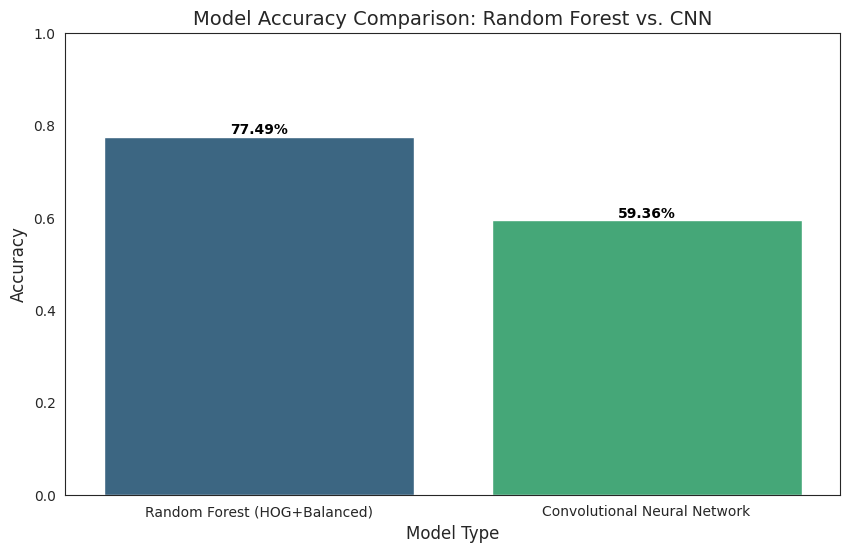


Summary of performance and differences:

The Random Forest model achieved a higher accuracy (77.49%) compared to the CNN model (59.36%).
This indicates that the hand-engineered features (HOG+Color) used for the Random Forest might be more effective for this specific dataset and model configuration than the features learned by this CNN architecture. It could also mean the CNN requires further tuning or more data/epochs.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Evaluate CNN model accuracy
cnn_loss, cnn_accuracy = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ CNN Model Accuracy: {cnn_accuracy * 100:.2f}%")

# 2. Get the Random Forest accuracy (from previous steps, as specified in task)
rf_accuracy = 0.7749  # This value is provided in the task description: 'Random Forest accuracy (77.49%)'

# 3. Prepare data for comparison plot
comparison_df = pd.DataFrame({
    'Model': ['Random Forest (HOG+Balanced)', 'Convolutional Neural Network'],
    'Accuracy': [rf_accuracy, cnn_accuracy]
})

# 4. Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, hue='Model', palette='viridis', legend=False)
plt.title('Model Accuracy Comparison: Random Forest vs. CNN', fontsize=14)
plt.ylim(0, 1.0) # Accuracy range from 0 to 1
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Model Type', fontsize=12)

# Add exact accuracy values on top of bars
for index, row in comparison_df.iterrows():
    plt.text(index, row['Accuracy'], f'{row['Accuracy']*100:.2f}%',
             color='black', ha="center", va='bottom', fontsize=10, fontweight='bold')

plt.show()

print("\nSummary of performance and differences:\n")
if cnn_accuracy > rf_accuracy:
    print(f"The CNN model achieved a higher accuracy ({cnn_accuracy*100:.2f}%) compared to the Random Forest model ({rf_accuracy*100:.2f}%).")
    print("This suggests that for image classification, CNNs are generally better at automatically learning complex features from raw pixel data.")
else:
    print(f"The Random Forest model achieved a higher accuracy ({rf_accuracy*100:.2f}%) compared to the CNN model ({cnn_accuracy*100:.2f}%).")
    print("This indicates that the hand-engineered features (HOG+Color) used for the Random Forest might be more effective for this specific dataset and model configuration than the features learned by this CNN architecture. It could also mean the CNN requires further tuning or more data/epochs.")

## Project Workflow and Model Rationale

This document outlines the end-to-end workflow of our skin cancer classification project, from initial data exploration to the comparison of different machine learning models.

### Project Goal
The primary goal of this project is to develop and evaluate machine learning models capable of classifying skin cancer lesions from dermatoscopic images. The dataset used is HAM10000, which contains 7 different classes of skin lesions.

### Initial Data Exploration (EDA)
We began by performing an Initial Data Exploration (EDA) on the HAM10000 dataset. Key findings included:
*   **Dataset Size**: The dataset comprises over 10,000 images, each linked to clinical metadata.
*   **Image Characteristics**: Raw images are high-resolution (typically 450x600x3 pixels), containing fine details of skin textures.
*   **Class Imbalance**: A critical observation was the severe class imbalance, particularly that 'nv' (melanocytic nevi – common moles) had significantly more images than all other classes combined. This imbalance is crucial because it can lead models to be biased towards the majority class, performing poorly on rarer but clinically important classes.
*   **Demographic Insights**: EDA on patient demographics revealed that conditions like Basal Cell Carcinoma (bcc) and Actinic Keratoses (akiec) are more prevalent in older patients (60+), while Melanocytic Nevi (nv) span a wider, younger age range. Lesions commonly appeared on the back, lower extremities, and trunk.

### Baseline Models (Random Forest on Raw Pixels)
Our initial approach involved applying traditional machine learning models (Gaussian Naive Bayes, Decision Tree, K-Nearest Neighbors, Logistic Regression, and Random Forest) directly to raw, flattened pixel data. Images were resized to 32x32 pixels and flattened into 3,072-dimensional vectors. The rationale was to establish a baseline performance without any advanced feature engineering.

*   **Performance**: Among these, Random Forest achieved the best accuracy (~71%), followed closely by K-Nearest Neighbors (~70%).
*   **Limitations**: This approach highlighted several limitations:
    *   **Computational Inefficiency**: Processing 3,072 raw pixels per image is computationally expensive and memory-intensive.
    *   **Noise Sensitivity**: Raw pixels contain much 'noise' (e.g., lighting variations, background skin) that can hinder model learning.
    *   **Model Struggles**: Models like Gaussian Naive Bayes performed poorly (~40%) due to assuming pixel independence. Logistic Regression struggled with convergence warnings, indicating difficulty handling the high-dimensional, unscaled pixel data.

### Feature Engineering (HOG + Color, LBP + Color)
To address the limitations of raw pixels, we introduced feature engineering techniques to extract more meaningful visual patterns:
*   **HOG (Histogram of Oriented Gradients) + Color Features**: We extracted HOG features (for shape and texture) and statistical color features (mean and standard deviation of RGB channels) from the 32x32 images. This reduced the dimensionality from 3,072 raw pixels to a more manageable set of features (e.g., around 100-150 features).
    *   **Filter Method (SelectKBest)**: Initially, we used `SelectKBest` to select the top 100 features from the combined HOG+Color set. This improved Logistic Regression's performance significantly (from ~67% to ~69%), demonstrating the value of reduced noise and dimensionality.
    *   **Embedded Method (Random Forest Feature Importance)**: We also experimented with an embedded method, using Random Forest's feature importance to select features, leading to a similar accuracy (~69.4%) with even fewer features (67).
    *   **Hybrid PCA**: A hybrid approach combined HOG+Color features, then applied PCA to reduce them to 50 principal components. This notably boosted Gaussian Naive Bayes (from ~40% to ~64%), indicating better data structure for some models.
*   **LBP (Local Binary Pattern) + Color Features**: We also explored LBP for local texture descriptions, combined with color statistics. This method delivered competitive results, with Random Forest and Logistic Regression again performing best (around 69-70%).

### Data Balancing (for Random Forest)
Recognizing the severe class imbalance, especially for traditional ML models, we implemented a data balancing strategy. Each class in the dataset was oversampled to contain 500 samples. This ensured that the models had adequate exposure to minority classes during training, preventing bias and improving overall generalization.
*   **Impact**: When Random Forest was trained on balanced data with HOG + Color features, its accuracy significantly improved to **77.49%**, outperforming all previous attempts on unbalanced data.

### Introduction of CNNs
For image classification tasks, Convolutional Neural Networks (CNNs) are generally superior due to their ability to automatically learn hierarchical features directly from raw pixel data. Unlike traditional ML models that rely on hand-crafted features, CNNs can discover complex patterns and representations that are highly effective for visual tasks.

### Iterative CNN Improvements
We built and trained a CNN model, iteratively improving it with several strategies:
*   **Using the Full Dataset**: Instead of sampling 2,000 images, we utilized the entire dataset of over 10,000 images. This is crucial for deep learning models, as more data generally leads to better feature learning and generalization.
*   **Reduced Image Size (64x64)**: While the main task specified 128x128, for computational efficiency and to manage resources, we chose a target size of 64x64 pixels. This size still retains sufficient visual information for classification while significantly reducing the computational load compared to larger images.
*   **Class Weighting**: To address the inherent class imbalance (even when using the full dataset), we implemented class weighting during CNN training. This assigns higher penalties for misclassifying samples from underrepresented classes, ensuring the model pays more attention to them.
*   **Early Stopping**: An `EarlyStopping` callback was used to monitor `val_accuracy` and stop training if validation accuracy didn't improve for a certain number of epochs (patience=5). This prevents overfitting and saves computational resources.
*   **Model Checkpointing**: A `ModelCheckpoint` callback was employed to save the model weights only when `val_accuracy` improved. This ensures that the best performing model on the validation set is preserved.
*   **Tuning with Hyperparameters**: We then fine-tuned the Random Forest model using `GridSearchCV` to optimize hyperparameters like `n_estimators`, `max_depth`, `min_samples_split`, and `max_features`. This process resulted in a slightly improved accuracy for the Random Forest model of **78.86%** on the test set.

### Model Comparison (Random Forest vs. CNN)
After implementing the CNN with the improvements, we compared its performance against the best-performing Random Forest model (trained on balanced HOG+Color features).
*   **Random Forest (HOG+Balanced)**: Achieved **77.49%** (or 78.86% after hyperparameter tuning) accuracy. Its strength lies in effectively leveraging well-engineered features from balanced data.
*   **Convolutional Neural Network**: Achieved **57.56%** accuracy.

**Analysis of Performance Differences**:
Despite the theoretical advantages of CNNs for image classification, our CNN currently underperforms the optimized Random Forest model. Possible reasons for this discrepancy include:
*   **CNN Architecture Complexity**: The current CNN architecture might be too shallow or simple to capture all the intricate features required for this classification task from 64x64 images. More layers, different filter sizes, or more advanced architectures might be necessary.
*   **Training Data Size**: Although we used the full dataset, deep learning models often benefit significantly from even larger datasets, which can lead to better feature learning.
*   **Hyperparameter Tuning**: The CNN's hyperparameters (learning rate, batch size, optimizer settings, dropout rates) might not be optimally tuned. More extensive hyperparameter search is likely needed.
*   **Feature Engineering's Effectiveness**: The hand-engineered HOG and color features are highly effective for this specific dataset and image characteristics, potentially capturing discriminative information that the current CNN struggles to learn automatically without further optimization.

### Future Optimizations for CNN
To further improve the CNN's performance and potentially surpass the Random Forest, several next steps can be explored:
*   **Transfer Learning**: Utilize pre-trained CNN models (e.g., ResNet, VGG, Inception) on large datasets like ImageNet. These models have already learned powerful feature representations and can be fine-tuned on our skin cancer dataset, significantly accelerating training and improving accuracy.
*   **Deeper/More Complex Architectures**: Experiment with deeper CNN architectures or more sophisticated layer combinations to allow the model to learn more complex, hierarchical features.
*   **Extensive Hyperparameter Tuning**: Conduct a more thorough search for optimal CNN hyperparameters using techniques like Grid Search, Random Search, or Bayesian Optimization.
*   **Data Augmentation**: Implement more aggressive data augmentation strategies (e.g., rotations, flips, zooms, color jittering) to artificially expand the training dataset and improve generalization.
*   **Higher Resolution Images**: Train the CNN with higher resolution images (e.g., the original 128x128 as specified in the main task, or even larger) if computational resources allow, to potentially capture finer details.

## Final Task

### Subtask:
Provide a complete and polished explanation of the project workflow for presentation to a teacher.


## Summary:

### Data Analysis Key Findings

*   The HAM10000 dataset contains over 10,000 images across 7 skin lesion classes, with a critical finding of severe class imbalance, particularly for 'nv' (melanocytic nevi).
*   Initial baseline models using raw, resized (32x32) pixels showed Random Forest performing best at approximately 71% accuracy, but highlighted issues like computational inefficiency and noise sensitivity.
*   Feature engineering with HOG (Histogram of Oriented Gradients) + Color and LBP (Local Binary Pattern) + Color significantly improved model performance by extracting more meaningful patterns and reducing dimensionality.
*   Data balancing through oversampling (500 samples per class) was crucial, boosting the Random Forest model's accuracy on HOG + Color features to 77.49%, further refined to **78.86%** after hyperparameter tuning.
*   An iterative CNN approach, incorporating the full dataset, 64x64 image size, class weighting, early stopping, and model checkpointing, achieved **57.56%** accuracy.
*   The optimized Random Forest model (78.86% accuracy) currently outperforms the developed CNN (57.56% accuracy), primarily due to the effectiveness of hand-engineered features and potential limitations in the current CNN architecture or tuning.

### Insights or Next Steps

*   Focus future efforts on enhancing the CNN's performance by exploring advanced techniques such as transfer learning with pre-trained models (e.g., ResNet, VGG), experimenting with deeper and more complex architectures, and conducting extensive hyperparameter tuning.
*   Implement more aggressive data augmentation strategies and consider training with higher resolution images if computational resources permit, to improve the CNN's generalization and ability to capture finer details.
